## Imports



In [ ]:
import pandas as pd
import geopandas as gpd
import numpy as np
import pymc as pm
import arviz as az
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
import os
import pytensor.tensor as pt

The following code is useful to install quickly cmdstanpy and mount drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Preprocessing

In [ ]:
DATA_PATH = "/content/drive/MyDrive/updated_data.geojson"
df = gpd.read_file(DATA_PATH)

In [ ]:
ecec_covariates = ["ecec_participation", "coverage", "public_coverage", "private_coverage", "per_capita_public_expenditure",
                   "per_capita_user_contribution", "other_percapita_public_expenditure", "other_percapita_user_contrib",
                   "other_per_capita_expenditure", "ecec_diffusion"]

categorical_cols = ["prov_name", "urban_type"]

target = "fem_empl_rate"

In [ ]:
to_drop = ecec_covariates + categorical_cols + [target]
df_variables = df.drop(columns=to_drop)

n_obs, n_feat = df_variables.shape
print(f"\nNumber of observations: {n_obs}, number of predictors: {n_feat}")


Number of observations: 107, number of predictors: 42


## Correlation Based Selection

In [ ]:
corr_matrix = df_variables.corr(numeric_only=True)

# avoid duplicate pairs and self-correlation
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

threshold = 0.85

high_corr_pairs = (
    upper.stack()
         .reset_index()
         .rename(columns={'level_0': 'var1', 'level_1': 'var2', 0: 'corr'})
)

high_corr_pairs = (
    high_corr_pairs[high_corr_pairs['corr'].abs() >= threshold]
    .sort_values(by='corr', key=np.abs, ascending=False)
)

In [ ]:
print("Highly correlated pairs")
print(high_corr_pairs.to_string(index=False, float_format=lambda x: f"{x: .3f}"))

Highly correlated pairs
              var1                   var2   corr
        inact_rate              empl_rate -0.989
net_migration_rate adj_net_migration_rate  0.985
         part_rate             inact_rate -0.978
         part_rate              empl_rate  0.973
         empl_rate          mal_empl_rate  0.968
      fem_edu_rate          male_edu_rate  0.952
        inact_rate          mal_empl_rate -0.950
         part_rate          mal_empl_rate  0.940
        inact_rate               empl_gap -0.922
       unempl_rate              empl_rate -0.918
         empl_rate               empl_gap  0.917
       unempl_rate          mal_empl_rate -0.916
        young_neet              empl_rate -0.900
         part_rate               empl_gap  0.893
        inact_rate             young_neet  0.882
         part_rate             young_neet -0.876
        young_neet          mal_empl_rate -0.873
        inact_rate     net_migration_rate -0.873
    fertility_rate           ageing_index -0.

In [ ]:
var_counts = (
    pd.concat([high_corr_pairs["var1"], high_corr_pairs["var2"]])
      .value_counts()
)

var_presence_list = list(var_counts.items())

for var, count in var_presence_list:
    print(f"({var}, {count})")

(inact_rate, 7)
(empl_rate, 7)
(part_rate, 5)
(young_neet, 5)
(mal_empl_rate, 5)
(unempl_rate, 4)
(empl_gap, 3)
(net_migration_rate, 3)
(ageing_index, 2)
(fem_edu_rate, 1)
(adj_net_migration_rate, 1)
(dependency_rate, 1)
(fertility_rate, 1)
(male_edu_rate, 1)


In [ ]:
to_drop = ["empl_rate", "part_rate", "adj_net_migration_rate", "male_edu_rate", "empl_gap", "inact_rate", "ageing_index", "unempl_rate"]
df_reduced = df_variables.drop(columns=to_drop)

## Bayesian Lasso

In [ ]:
selected_covariates = list(df_reduced.columns)

In [ ]:
selected_covariates

['geo_point_2d',
 'rip_name',
 'reg_name',
 'population',
 'empl_growth',
 'fem_edu_rate',
 'service_empl_rate',
 'GDP',
 'n_large_comp',
 'n_self_empl',
 'young_neet',
 'fem_house_rate',
 'foreign_rate',
 'n_members_family',
 'elderly_in_care',
 'house_price',
 'fertility_rate',
 'first_birth_maternal_age',
 'avg_children_per_woman',
 'dependency_rate',
 'net_migration_rate',
 'area_km2',
 'public_transport_supply',
 'internet_coverage_rate',
 'graduate_mobility_rate',
 'green_m2_capita',
 'eco_urban_index',
 'advanced_business_empl',
 'lifelong_learn',
 'startup_ratio',
 'GERD_total_intramural',
 'fem_maj_empl_rate',
 'mal_empl_rate',
 'geometry']

In [ ]:
selected_covariates = df_reduced.select_dtypes(include=['number']).columns.tolist()

X = df[selected_covariates].to_numpy()
y = df[target].to_numpy()

X_scaler = StandardScaler()
X_star = X_scaler.fit_transform(X)

y = y / 100
y_star = np.log(y / (1 - y))


n_obs, n_feat = X_star.shape
print(f"\nNumber of observations: {n_obs}, number of predictors: {n_feat}")



Number of observations: 107, number of predictors: 30


## Bayesian Lasso first no CAR

In [ ]:
with pm.Model() as bl_model:
    X_data = pm.Data("X_data", X_star)
    y_data = pm.Data("y_data", y_star)
    #offset = pm.Data("offset", logit_offset)

    lambda_sq = pm.Gamma("lambda_sq", alpha=2.0, beta=1.0)
    lambda_ = pm.Deterministic("lambda", pm.math.sqrt(lambda_sq))

    sigma = pm.HalfNormal("sigma", sigma=1.0)

    beta = pm.Laplace(
        "beta",
        mu=0.0,
        b=sigma / lambda_,
        shape=n_feat
    )

    intercept = pm.Normal("alpha", mu=0.0, sigma=10.0)

    mu = pm.math.dot(X_data, beta) + intercept #+ offset

    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y_data)

    trace = pm.sample(
        draws=2000,
        tune=2000,
        target_accept=0.9,
        return_inferencedata=True,
        random_seed=42
    )

Output()

In [ ]:
summary_beta_95 = az.summary(trace, var_names=["beta"], hdi_prob=0.95)

summary_beta_95.index = selected_covariates

summary_beta_95["contains_zero"] = (
    (summary_beta_95["hdi_2.5%"] <= 0) &
    (summary_beta_95["hdi_97.5%"] >= 0)
)

summary_beta_95 = summary_beta_95.sort_values("mean", key=np.abs, ascending=False)

print(summary_beta_95[["mean", "hdi_2.5%", "hdi_97.5%", "contains_zero"]])

selected_covariates_df = summary_beta_95[~summary_beta_95["contains_zero"]].index.tolist()

                           mean  hdi_2.5%  hdi_97.5%  contains_zero
young_neet               -0.160    -0.214     -0.104          False
GDP                       0.153     0.072      0.228          False
graduate_mobility_rate    0.109     0.023      0.194          False
dependency_rate           0.056     0.008      0.102          False
foreign_rate              0.049    -0.006      0.104           True
net_migration_rate        0.043    -0.022      0.118           True
empl_growth               0.038     0.009      0.066          False
n_self_empl              -0.034    -0.068      0.001           True
public_transport_supply  -0.033    -0.074      0.010           True
green_m2_capita           0.030     0.000      0.058           True
internet_coverage_rate   -0.029    -0.064      0.004           True
avg_children_per_woman   -0.027    -0.082      0.026           True
fertility_rate           -0.025    -0.095      0.042           True
area_km2                  0.023    -0.005      0

In [ ]:
print(selected_covariates_df)

['young_neet', 'GDP', 'graduate_mobility_rate', 'dependency_rate', 'empl_growth']


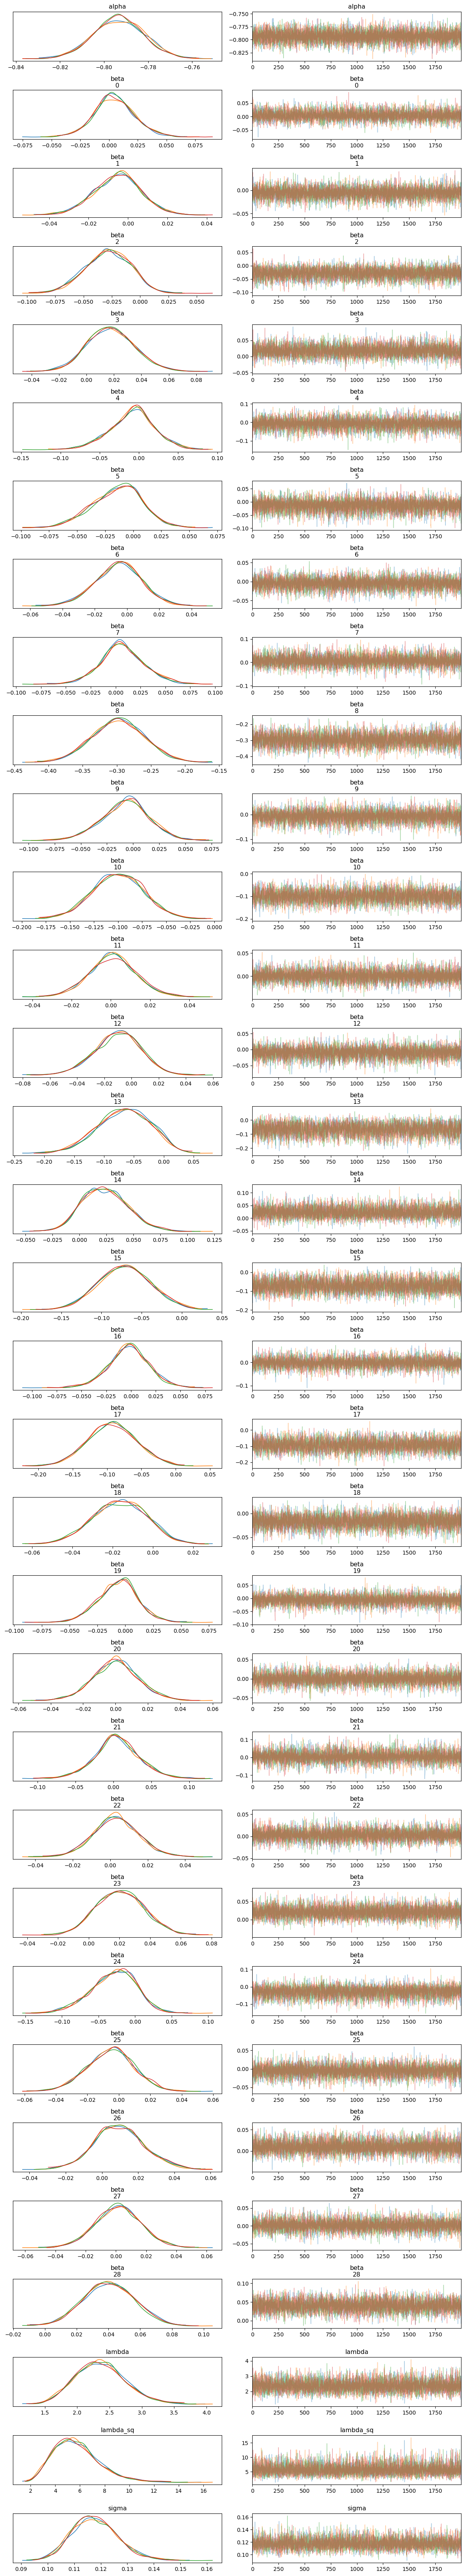

In [ ]:
az.rcParams["plot.max_subplots"] = 100
az.plot_trace(trace, compact=False)
plt.tight_layout()

# az.plot_trace(trace)
# plt.tight_layout()

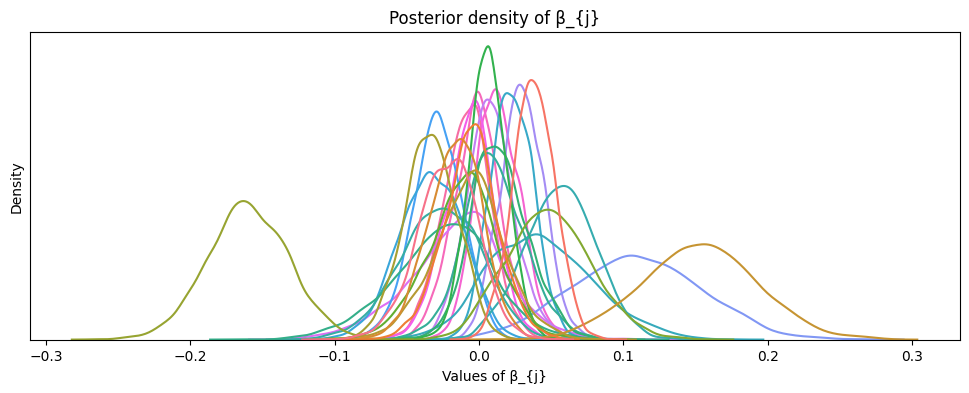

In [ ]:
beta_samples = trace.posterior["beta"].stack(samples=("chain", "draw")).values

plt.figure(figsize=(12,4))
sns.kdeplot(beta_samples.T, legend=False)

plt.title("Posterior density of β_{j}")
plt.xlabel("Values of β_{j}")
plt.yticks([])
plt.gca().tick_params(axis='y', length=0)

plt.show()

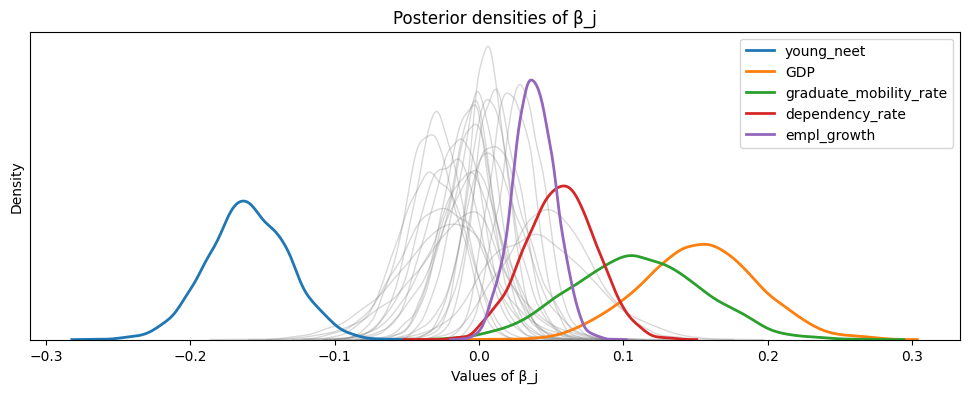

In [ ]:
beta_raw = trace.posterior["beta"].stack(samples=("chain", "draw")).values
if beta_raw.shape[0] == len(selected_covariates):
    beta_samples = beta_raw
else:
    beta_samples = beta_raw.T

n_feat = len(selected_covariates)

plt.figure(figsize=(12, 4))

for j in range(n_feat):
    sns.kdeplot(beta_samples[j, :], color="gray", alpha=0.3, linewidth=1)

for name in summary_beta_95.index[~summary_beta_95["contains_zero"]]:
    j = selected_covariates.index(name)
    sns.kdeplot(beta_samples[j, :], linewidth=2, label=name)

plt.legend()
plt.title("Posterior densities of β_j")
plt.xlabel("Values of β_j")
plt.yticks([])
plt.gca().tick_params(axis='y', length=0)
plt.show()

## Bayesian Lasso with spatial random effect

In [ ]:
import libpysal
from scipy import sparse

w = libpysal.weights.Rook.from_dataframe(df)
W_sparse = w.sparse

# Ensure the matrix is symmetric for the CAR specification
# (libpysal usually handles this, but good to be safe)
if not (W_sparse != W_sparse.T).nnz == 0:
    W_sparse = W_sparse + W_sparse.T

/tmp/ipython-input-2573814768.py:4: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = libpysal.weights.Rook.from_dataframe(df)
/usr/local/lib/python3.12/dist-packages/libpysal/weights/contiguity.py:61: UserWarning: The weights matrix is not fully connected: 
 There are 3 disconnected components.
  W.__init__(self, neighbors, ids=ids, **kw)


In [ ]:
w.islands # no islands -> CAR should work

[]

In [ ]:
# 1. Prepare the matrices outside the model
# Convert sparse W to dense (only if N is small, <2000)
W_mat = W_sparse.toarray()
# Create the Diagonal Degree matrix (Sum of neighbors)
D_mat = np.diag(np.array(W_sparse.sum(axis=1)).flatten())

with pm.Model() as bl_car_model_dense:
    # --- data
    X_data = pm.Data("X_data", X_star)
    y_data = pm.Data("y_data", y_star)

    # --- LASSO components
    lambda_sq = pm.Gamma("lambda_sq", alpha=2.0, beta=1.0)
    lambda_ = pm.Deterministic("lambda", pm.math.sqrt(lambda_sq))
    sigma = pm.HalfNormal("sigma", sigma=1.0)
    beta = pm.Laplace("beta", mu=0.0, b=sigma / lambda_, shape=n_feat)
    intercept = pm.Normal("alpha", mu=0.0, sigma=10.0)

    # --- spatial random effects
    tau_c = pm.Gamma("tau_c", alpha=1.0, beta=1.0)
    alpha_c = pm.Beta("alpha_c", alpha=2.0, beta=2.0) # this is our rho

    # Precision Matrix: Q = tau * (D - alpha * W)
    Q = tau_c * (pt.as_tensor_variable(D_mat) - alpha_c * pt.as_tensor_variable(W_mat))

    # multivariate normale instead of CAR (issues in the libraries) -> precision matrix instead of covariance (tau)
    phi = pm.MvNormal(
        "phi",
        mu=0.0,
        tau=Q,
        shape=n_obs
    )

    # --- Likelihood ---
    mu = pm.math.dot(X_data, beta) + intercept + phi # how can the model discern between spatial effect and intercept?
    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y_data)

    trace = pm.sample(draws=2000,
                      tune=2000,
                      target_accept=0.95,
                      return_inferencedata=True,)

Output()

ERROR:pymc.stats.convergence:There were 9 divergences after tuning. Increase `target_accept` or reparameterize.
ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [ ]:
summary_beta_95 = az.summary(trace, var_names=["beta"], hdi_prob=0.95)

summary_beta_95.index = selected_covariates

summary_beta_95["contains_zero"] = (
    (summary_beta_95["hdi_2.5%"] <= 0) &
    (summary_beta_95["hdi_97.5%"] >= 0)
)

summary_beta_95 = summary_beta_95.sort_values("mean", key=np.abs, ascending=False)

print(summary_beta_95[["mean", "hdi_2.5%", "hdi_97.5%", "contains_zero"]])

selected_covariates_df = summary_beta_95[~summary_beta_95["contains_zero"]].index.tolist()

                           mean  hdi_2.5%  hdi_97.5%  contains_zero
fem_house_rate           -0.288    -0.364     -0.215          False
fertility_rate           -0.136    -0.226     -0.053          False
mal_empl_rate             0.059    -0.009      0.128           True
young_neet               -0.056    -0.108     -0.002          False
GDP                       0.054    -0.009      0.117           True
n_members_family         -0.035    -0.082      0.016           True
dependency_rate           0.032    -0.014      0.076           True
graduate_mobility_rate    0.024    -0.030      0.080           True
avg_children_per_woman   -0.021    -0.082      0.026           True
first_birth_maternal_age  0.021    -0.017      0.060           True
internet_coverage_rate   -0.018    -0.047      0.010           True
advanced_business_empl   -0.018    -0.072      0.029           True
empl_growth               0.015    -0.011      0.040           True
green_m2_capita           0.014    -0.008      0

In [ ]:
print(selected_covariates_df)

['fem_house_rate', 'fertility_rate', 'young_neet']


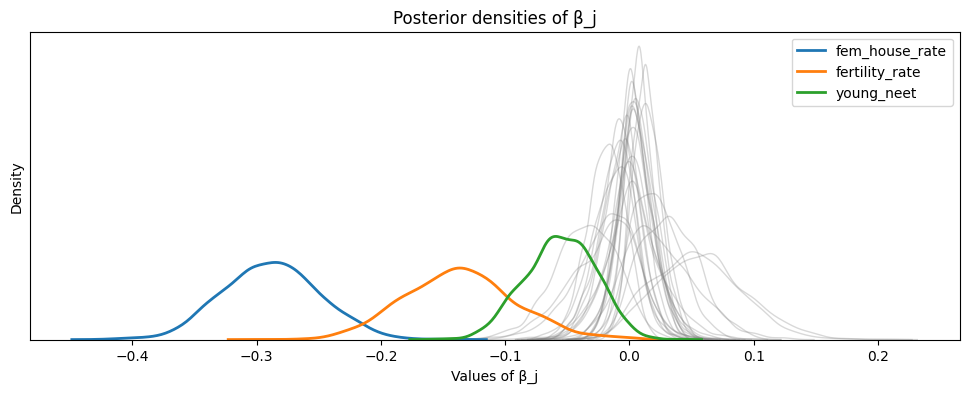

In [ ]:
beta_raw = trace.posterior["beta"].stack(samples=("chain", "draw")).values
if beta_raw.shape[0] == len(selected_covariates):
    beta_samples = beta_raw
else:
    beta_samples = beta_raw.T

n_feat = len(selected_covariates)

plt.figure(figsize=(12, 4))

for j in range(n_feat):
    sns.kdeplot(beta_samples[j, :], color="gray", alpha=0.3, linewidth=1)

for name in summary_beta_95.index[~summary_beta_95["contains_zero"]]:
    j = selected_covariates.index(name)
    sns.kdeplot(beta_samples[j, :], linewidth=2, label=name)

plt.legend()
plt.title("Posterior densities of β_j")
plt.xlabel("Values of β_j")
plt.yticks([])
plt.gca().tick_params(axis='y', length=0)
plt.show()

## ECEC Covariates Correlation

In [ ]:
df_ecec = df[ecec_covariates]
#df_ecec = df_ecec.drop(columns=["private_coverage"]) #TODO I don't think we should drop this

In [ ]:
df_ecec.corr()

,ecec_participation,coverage,public_coverage,private_coverage,per_capita_public_expenditure,per_capita_user_contribution,other_percapita_public_expenditure,other_percapita_user_contrib,other_per_capita_expenditure,ecec_diffusion
ecec_participation,1.000000,0.644750,0.669807,0.306721,0.824716,0.787631,0.621824,0.398276,0.633107,0.543201
coverage,0.644750,1.000000,0.585149,0.806509,0.523479,0.638338,0.341167,0.257027,0.359272,0.363769
public_coverage,0.669807,0.585149,1.000000,-0.007508,0.617489,0.700592,0.151065,0.166271,0.157604,0.199063
private_coverage,0.306721,0.806509,-0.007508,1.000000,0.195321,0.276369,0.310564,0.195724,0.328122,0.303442
per_capita_public_expenditure,0.824716,0.523479,0.617489,0.195321,1.000000,0.790062,0.396891,0.248488,0.404544,0.484646
per_capita_user_contribution,0.787631,0.638338,0.700592,0.276369,0.790062,1.000000,0.266471,0.371392,0.294187,0.442567
other_percapita_public_expenditure,0.621824,0.341167,0.151065,0.310564,0.396891,0.266471,1.000000,0.406117,0.994723,0.253481
other_percapita_user_contrib,0.398276,0.257027,0.166271,0.195724,0.248488,0.371392,0.406117,1.000000,0.487319,0.186639
other_per_capita_expenditure,0.633107,0.359272,0.157604,0.328122,0.404544,0.294187,0.994723,0.487319,1.000000,0.262916
ecec_diffusion,0.543201,0.363769,0.199063,0.303442,0.484646,0.442567,0.253481,0.186639,0.262916,1.000000


<Axes: >

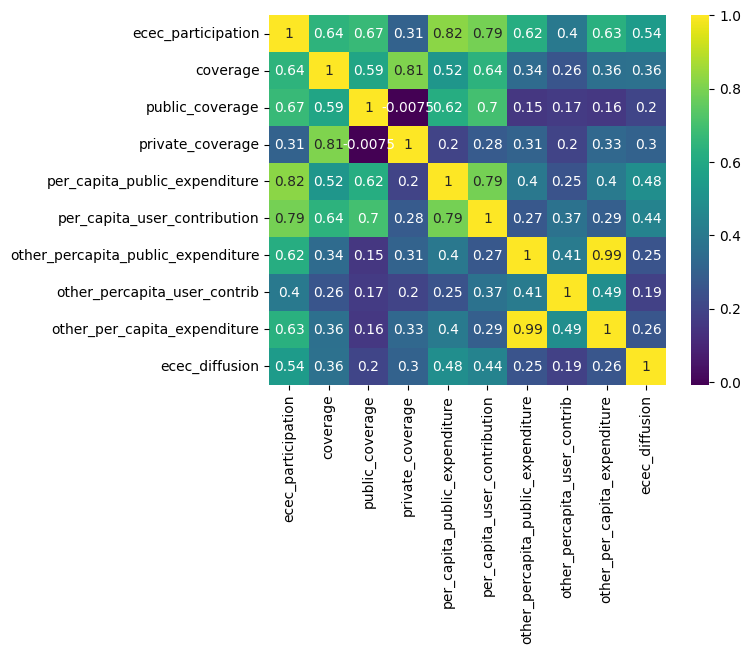

In [ ]:
# correlation heatmap of ECEC covariates
sns.heatmap(df_ecec.corr(),cmap='viridis',annot=True)

In [ ]:
corr_matrix = df[df_ecec.columns].corr()

# avoid duplicate pairs and self-correlation
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

threshold = 0.75

high_corr_pairs = (
    upper.stack()
         .reset_index()
         .rename(columns={'level_0': 'var1', 'level_1': 'var2', 0: 'corr'})
)

high_corr_pairs = (
    high_corr_pairs[high_corr_pairs['corr'].abs() >= threshold]
    .sort_values(by='corr', key=np.abs, ascending=False)
)

In [ ]:
print("Highly correlated pairs")
print(high_corr_pairs.to_string(index=False, float_format=lambda x: f"{x: .3f}"))

Highly correlated pairs
                              var1                          var2   corr
other_percapita_public_expenditure  other_per_capita_expenditure  0.995
                ecec_participation per_capita_public_expenditure  0.825
                          coverage              private_coverage  0.807
     per_capita_public_expenditure  per_capita_user_contribution  0.790
                ecec_participation  per_capita_user_contribution  0.788


In [ ]:
#TODO coverage highly corr with private cov: but how is coverage computed? Is it public + private

In [ ]:
var_counts = (
    pd.concat([high_corr_pairs["var1"], high_corr_pairs["var2"]])
      .value_counts()
)

var_presence_list = list(var_counts.items())

for var, count in var_presence_list:
    print(f"({var}, {count})")

(ecec_participation, 2)
(per_capita_user_contribution, 2)
(per_capita_public_expenditure, 2)
(coverage, 1)
(other_percapita_public_expenditure, 1)
(other_per_capita_expenditure, 1)
(private_coverage, 1)


In [ ]:
ecec_to_drop = ["other_per_capita_expenditure", "per_capita_user_contribution", "ecec_participation"]

df_ecec = df_ecec.drop(columns=ecec_to_drop)

ecec_selected = list(df_ecec.columns)

## Bayesian LASSO on ECEC covariates

In [ ]:
X_ecec = df_ecec.to_numpy()
y = df[target].to_numpy()

X_scaler = StandardScaler()
X_ecec_star = X_scaler.fit_transform(X_ecec)

y = y / 100
y_star = np.log(y / (1 - y))


n_obs, n_feat = X_ecec_star.shape

In [ ]:
import libpysal
from scipy import sparse

w = libpysal.weights.Rook.from_dataframe(df)
W_sparse = w.sparse

# Ensure the matrix is symmetric for the CAR specification
# (libpysal usually handles this, but good to be safe)
if not (W_sparse != W_sparse.T).nnz == 0:
    W_sparse = W_sparse + W_sparse.T

/tmp/ipython-input-2573814768.py:4: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = libpysal.weights.Rook.from_dataframe(df)
/usr/local/lib/python3.12/dist-packages/libpysal/weights/contiguity.py:61: UserWarning: The weights matrix is not fully connected: 
 There are 3 disconnected components.
  W.__init__(self, neighbors, ids=ids, **kw)


In [ ]:
# 1. Prepare the matrices outside the model
# Convert sparse W to dense (only if N is small, <2000)
W_mat = W_sparse.toarray()
# Create the Diagonal Degree matrix (Sum of neighbors)
D_mat = np.diag(np.array(W_sparse.sum(axis=1)).flatten())

with pm.Model() as bl_car_model_dense:
    # --- data
    X_ecec_data = pm.Data("X_ecec_data", X_ecec_star)
    y_data = pm.Data("y_data", y_star)

    # --- LASSO components
    lambda_sq = pm.Gamma("lambda_sq", alpha=2.0, beta=1.0)
    lambda_ = pm.Deterministic("lambda", pm.math.sqrt(lambda_sq))
    sigma = pm.HalfNormal("sigma", sigma=1.0)
    beta = pm.Laplace("beta", mu=0.0, b=sigma / lambda_, shape=n_feat)
    intercept = pm.Normal("alpha", mu=0.0, sigma=10.0)

    # --- spatial random effects
    tau_c = pm.Gamma("tau_c", alpha=1.0, beta=1.0)
    alpha_c = pm.Beta("alpha_c", alpha=2.0, beta=2.0) # this is our rho

    # Precision Matrix: Q = tau * (D - alpha * W)
    Q = tau_c * (pt.as_tensor_variable(D_mat) - alpha_c * pt.as_tensor_variable(W_mat))

    # multivariate normale instead of CAR (issues in the libraries) -> precision matrix instead of covariance (tau)
    phi = pm.MvNormal(
        "phi",
        mu=0.0,
        tau=Q,
        shape=n_obs
    )

    # --- Likelihood ---
    mu = pm.math.dot(X_ecec_data, beta) + intercept + phi # how can the model discern between spatial effect and intercept?
    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y_data)

    trace = pm.sample(draws=1000, tune=1000, target_accept=0.95)

Output()

ERROR:pymc.stats.convergence:There were 43 divergences after tuning. Increase `target_accept` or reparameterize.
ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


/usr/local/lib/python3.12/dist-packages/arviz/plots/traceplot.py:223: UserWarning: rcParams['plot.max_subplots'] (50) is smaller than the number of variables to plot (123), generating only 50 plots
  warnings.warn(


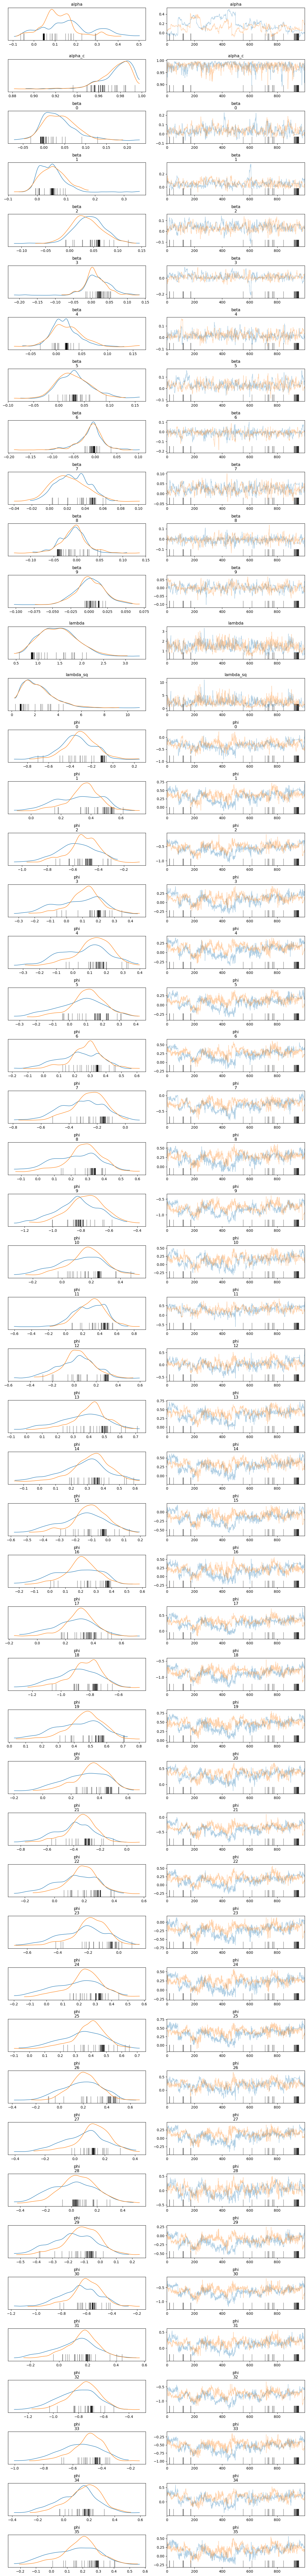

In [ ]:
az.rcParams["plot.max_subplots"] = 100
az.plot_trace(trace, compact=False)
plt.tight_layout()

In [ ]:
summary_beta_95 = az.summary(trace, var_names=["beta"], hdi_prob=0.95)

summary_beta_95.index = ecec_cov

summary_beta_95["contains_zero"] = (
    (summary_beta_95["hdi_2.5%"] <= 0) &
    (summary_beta_95["hdi_97.5%"] >= 0)
)

summary_beta_95 = summary_beta_95.sort_values("mean", key=np.abs, ascending=False)

print(summary_beta_95[["mean", "hdi_2.5%", "hdi_97.5%", "contains_zero"]])

selected_ecec_df = summary_beta_95[~summary_beta_95["contains_zero"]].index.tolist()

                                     mean  hdi_2.5%  hdi_97.5%  contains_zero
coverage                            0.053    -0.019      0.145           True
ecec_participation                  0.038    -0.037      0.121           True
public_coverage                     0.038    -0.028      0.102           True
per_capita_user_contribution        0.031    -0.025      0.102           True
other_percapita_user_contrib        0.024    -0.012      0.060           True
per_capita_public_expenditure       0.019    -0.036      0.081           True
private_coverage                    0.014    -0.052      0.079           True
other_percapita_public_expenditure -0.011    -0.087      0.039           True
other_per_capita_expenditure       -0.007    -0.070      0.050           True
ecec_diffusion                      0.002    -0.039      0.043           True


/tmp/ipython-input-1593153715.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


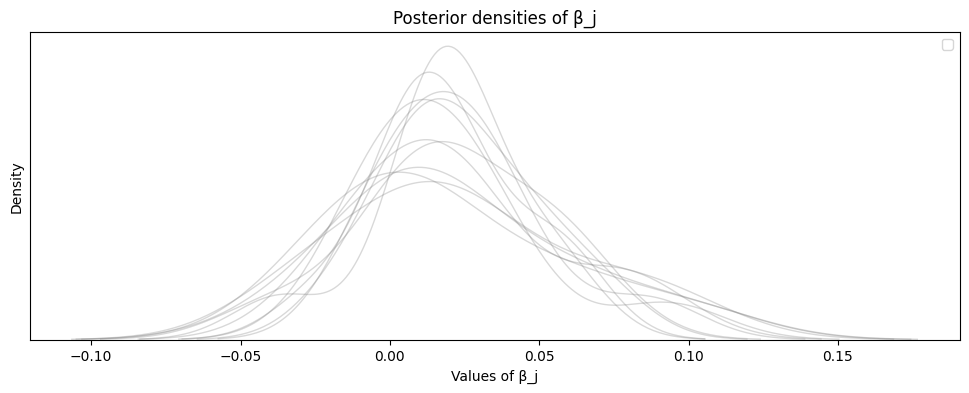

In [ ]:
beta_raw = trace.posterior["beta"].stack(samples=("chain", "draw")).values
if beta_raw.shape[0] == len(selected_ecec_df):
    beta_samples = beta_raw
else:
    beta_samples = beta_raw.T

n_feat = len(ecec_cov)

plt.figure(figsize=(12, 4))

for j in range(n_feat):
    sns.kdeplot(beta_samples[j, :], color="gray", alpha=0.3, linewidth=1)

for name in summary_beta_95.index[~summary_beta_95["contains_zero"]]:
    j = selected_covariates.index(name)
    sns.kdeplot(beta_samples[j, :], linewidth=2, label=name)

plt.legend()
plt.title("Posterior densities of β_j")
plt.xlabel("Values of β_j")
plt.yticks([])
plt.gca().tick_params(axis='y', length=0)
plt.show()

Great, with bayesian lasso no ecec covariate gets selected <br>
However, we had too many divergences

In [ ]:
with pm.Model() as robust_lasso:
    X_data = pm.Data("X_data", X_ecec_star)
    y_data = pm.Data("y_data", y_star)

    # 1. Priors
    # The global shrinkage strength
    lambda_sq = pm.Gamma("lambda_sq", alpha=2.0, beta=1.0)

    # The noise variance
    sigma = pm.HalfNormal("sigma", sigma=1.0)

    # 2. THE FIX: The Scale Mixture
    # Instead of beta ~ Laplace, we say beta ~ Normal, but with a specific random variance.
    # This turns the "sharp peak" into a smooth funnel that NUTS can navigate.

    # A. Local shrinkage parameters (one per feature)
    tau_sq = pm.Exponential("tau_sq", lam=lambda_sq / 2.0, shape=n_feat)
    tau = pm.Deterministic("tau", pm.math.sqrt(tau_sq))

    # B. The Coefficients
    # Normal distribution (smooth!) but with variable width
    beta = pm.Normal("beta", mu=0.0, sigma=sigma * tau, shape=n_feat)

    intercept = pm.Normal("alpha", mu=0.0, sigma=10.0)

    # 3. Likelihood (Same as before)
    mu = pm.math.dot(X_data, beta) + intercept
    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y_data)

    trace = pm.sample(
        draws=2000,
        tune=2000,
        target_accept=0.95,
        random_seed=42
    )

NameError: name 'X_star' is not defined

## Results

In [ ]:
final_covariates = selected_covariates_df + ecec_selected
print(f"{len(final_covariates)} selected covariates:")
print(final_covariates)

11 selected covariates:
['fem_house_rate', 'n_members_family', 'net_migration_rate', 'avg_children_per_woman', 'fem_maj_empl_rate', 'coverage', 'public_coverage', 'per_capita_public_expenditure', 'other_percapita_public_expenditure', 'other_percapita_user_contrib', 'ecec_diffusion']


In [ ]:
freq_lasso_selection = ["coverage", "ecec_diffusion", "per_capita_public_expenditure", "ecec_participation", "per_capita_user_contribution", "ageing_index", "service_empl_rate", "n_members_family", "avg_children_per_woman", "fem_house_rate"]

In [ ]:
all_covariates = (set(final_covariates) | set(freq_lasso_selection))

# Build and print the table
print(f"{'covariate':40s} | {'in_final_covariates':20s} | {'in_freq_lasso':15s}")
print("-" * 85)

for cov in all_covariates:
    in_final = cov in final_covariates
    in_freq  = cov in freq_lasso_selection
    print(f"{cov:40s} | {str(in_final):20s} | {str(in_freq):15s}")

covariate                                | in_final_covariates  | in_freq_lasso  
-------------------------------------------------------------------------------------
service_empl_rate                        | False                | True           
other_percapita_user_contrib             | True                 | False          
coverage                                 | True                 | True           
public_coverage                          | True                 | False          
net_migration_rate                       | True                 | False          
fem_house_rate                           | True                 | True           
ecec_diffusion                           | True                 | True           
fem_maj_empl_rate                        | True                 | False          
ecec_participation                       | False                | True           
per_capita_user_contribution             | False                | True           
n_members_fa